# Pipeline C — Ensemble of Pipeline A and Pipeline B (Aug 25 rebuild)

Original (Aug 24) version of this notebook ensembled Pipeline A (flat LightGBM, $128.09 MAE)
and Pipeline B (two-stage, $105.79) and found the CV-selected blend *underperformed* Pipeline
B alone on the holdout — diagnosed as fold 2's Stage-1 weakness distorting the CV weight
search (see [Aug_24_Plan.md](../progress/Aug_24_Plan.md)).

Since then, two things closed most of the A-vs-B gap: Pipeline A gained a `market_trend`
feature (STL trend + damped-Holt forecast of the daily $/mile level, used as an input feature
rather than a target-divisor) that took it from $128.09 to $109.93, and swapping XGBoost in
for Pipeline A's LightGBM took it to **$106.90** — within ~1% of Pipeline B's $105.79. This
notebook re-runs the ensemble check using each pipeline's *best known config* — Component A =
XGBoost + `market_trend`, Component B = LightGBM Stage 2 (its XGBoost swap was a wash, see
`pipeline_b.ipynb` §5b) — since the original "doesn't help" finding was diagnosed under a
17%-gap regime that no longer holds.

In [1]:
import warnings

import lightgbm as lgb
import xgboost as xgb
from lightgbm.basic import LGBMDeprecationWarning
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from data import ExpandingWindowCVConfig, ExpandingWindowCVSplitter, load_data
from eval import mae, rmse, smape

warnings.filterwarnings("ignore", category=LGBMDeprecationWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 0

## 1. Load & clean

Same as both pipelines: `weight = weight.abs()` (sign-flip bug), plus `market_missing`, which
Component A's raw market-feature block still uses (`use_market=True`, established in
`pipeline_a.ipynb` §3).

In [2]:
raw = load_data()
raw["date"] = pd.to_datetime(raw["date"])

clean = raw.copy()
clean["weight"] = clean["weight"].abs()
clean["market_missing"] = clean["market_index"].isna().astype(int)

print(f"raw: {raw.shape}")
print(f"negative-weight rows fixed: {(raw['weight'] < 0).sum()}")

raw: (48000, 14)
negative-weight rows fixed: 292


## 2. Shared feature engineering

Geo/date features, the shrinkage lane encoder, and `market_trend` are fit **once** here and
shared — `build_features` returns full-column frames; each component selects its own subset.
`market_trend` and the raw market block (`market_index`/`quote_signal`/`market_missing`) are
Component-A-only (Component B's whole design point is not needing them, see
`pipeline_b.ipynb`'s intro).

In [3]:
def haversine_miles(lat1, lon1, lat2, lon2):
    r = 3958.8
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    return 2 * r * np.arcsin(
        np.sqrt(np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2)
    )


def add_shipment_geo_date_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["log_distance"] = np.log1p(out["distance"])
    out["haversine"] = haversine_miles(out["pickup_lat"], out["pickup_lon"], out["delivery_lat"], out["delivery_lon"])
    out["circuity"] = out["distance"] / out["haversine"]
    out["lon_delta"] = out["delivery_lon"] - out["pickup_lon"]

    doy = out["date"].dt.dayofyear
    dow = out["date"].dt.dayofweek
    out["month_sin"] = np.sin(2 * np.pi * out["date"].dt.month / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["date"].dt.month / 12)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365)
    out["is_weekend"] = (dow >= 5).astype(int)
    out["days_since_start"] = (out["date"] - pd.Timestamp("2025-01-01")).dt.days

    christmas = pd.Timestamp("2025-12-25")
    new_year = pd.Timestamp("2026-01-01")
    out["days_to_christmas"] = (christmas - out["date"]).dt.days
    out["days_to_new_year"] = (new_year - out["date"]).dt.days

    out["equipment"] = out["equipment"].astype("category")
    return out


def fit_daily_trend_model(train_raw: pd.DataFrame, period: int = 7) -> dict:
    """STL trend + damped-Holt forecast of daily median $/mile (pipeline_a.ipynb, Aug 24)."""
    daily = (
        (train_raw["posted_rate"] / train_raw["distance"])
        .groupby(train_raw["date"]).median()
        .asfreq("D")
        .interpolate(limit_direction="both")
    )
    if len(daily) < 14:
        return {"mode": "flat", "flat": float(daily.mean())}
    trend = STL(daily, period=7, robust=True).fit().trend
    holt = Holt(trend, damped_trend=True).fit(optimized=True)
    return {"mode": "smooth", "trend": trend, "holt": holt, "last_date": trend.index.max()}


def predict_daily_trend(model: dict, dates: pd.Series) -> np.ndarray:
    dates = pd.DatetimeIndex(dates)
    if model["mode"] == "flat":
        return np.full(len(dates), model["flat"])
    trend, holt, last_date = model["trend"], model["holt"], model["last_date"]
    out = np.empty(len(dates), dtype=float)
    in_range = dates <= last_date
    if in_range.any():
        out[in_range] = trend.reindex(dates[in_range]).to_numpy()
    if (~in_range).any():
        future = dates[~in_range]
        horizon = int((future.max() - last_date).days)
        fcast = holt.forecast(horizon).to_numpy()
        step = (future - last_date).days.to_numpy() - 1
        out[~in_range] = fcast[step]
    return out

In [4]:
def fit_lane_target_encoder_shrink(train_df: pd.DataFrame, target: pd.Series, k_lane: float, k_city: float) -> dict:
    """Count-weighted empirical-Bayes shrinkage lane encoder (pipeline_a.ipynb, Aug 24 fix)."""
    y = target.reindex(train_df.index)
    global_mean = y.mean()

    pickup_stats = y.groupby(train_df["pickup"]).agg(["mean", "count"])
    delivery_stats = y.groupby(train_df["delivery"]).agg(["mean", "count"])
    pickup_shrunk = (pickup_stats["count"] * pickup_stats["mean"] + k_city * global_mean) / (pickup_stats["count"] + k_city)
    delivery_shrunk = (delivery_stats["count"] * delivery_stats["mean"] + k_city * global_mean) / (delivery_stats["count"] + k_city)

    lane_stats = y.groupby([train_df["pickup"], train_df["delivery"]]).agg(["mean", "count"])
    return {
        "lane_mean": lane_stats["mean"],
        "lane_count": lane_stats["count"],
        "pickup_shrunk": pickup_shrunk,
        "delivery_shrunk": delivery_shrunk,
        "global": global_mean,
        "k_lane": k_lane,
    }


def apply_lane_target_encoder_shrink(df: pd.DataFrame, encoder: dict) -> pd.Series:
    global_mean, k_lane = encoder["global"], encoder["k_lane"]
    pu = encoder["pickup_shrunk"].reindex(df["pickup"]).to_numpy()
    de = encoder["delivery_shrunk"].reindex(df["delivery"]).to_numpy()
    pu = np.where(np.isnan(pu), global_mean, pu)
    de = np.where(np.isnan(de), global_mean, de)
    city_prior = (pu + de) / 2.0

    lane_idx = pd.MultiIndex.from_arrays([df["pickup"], df["delivery"]])
    lane_mean = np.nan_to_num(encoder["lane_mean"].reindex(lane_idx).to_numpy(), nan=0.0)
    lane_count = np.nan_to_num(encoder["lane_count"].reindex(lane_idx).to_numpy(), nan=0.0)

    enc = (lane_count * lane_mean + k_lane * city_prior) / (lane_count + k_lane)
    return pd.Series(enc, index=df.index, name="lane_target_enc")


K_LANE, K_CITY = 60, 15  # selected by pipeline_a.ipynb §3b's CV grid search

In [5]:
NUMERIC_BASE = [
    "distance", "log_distance", "weight", "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "circuity", "lon_delta", "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",
    "is_weekend", "days_since_start", "days_to_christmas", "days_to_new_year", "lane_target_enc",
]
MARKET_FEATURES = ["market_index", "quote_signal", "market_missing"]
CATEGORICAL = ["equipment"]

A_FEATURE_COLS = NUMERIC_BASE + ["market_trend"] + CATEGORICAL + MARKET_FEATURES  # use_market=True (Aug 22 finding)
B_FEATURE_COLS = NUMERIC_BASE + CATEGORICAL  # no market_trend, no raw market features


def build_features(train_raw: pd.DataFrame, apply_raw: pd.DataFrame):
    """Fit geo/date features, market_trend, and the shrinkage lane encoder on train_raw only,
    apply to both. Returns full-column (train_feat, apply_feat) -- callers select
    A_FEATURE_COLS/B_FEATURE_COLS.
    """
    train_feat = add_shipment_geo_date_features(train_raw)
    apply_feat = add_shipment_geo_date_features(apply_raw)

    trend_model = fit_daily_trend_model(train_raw)
    train_feat["market_trend"] = predict_daily_trend(trend_model, train_feat["date"])
    apply_feat["market_trend"] = predict_daily_trend(trend_model, apply_feat["date"])

    y_train_log = np.log1p(train_raw["posted_rate"])
    enc = fit_lane_target_encoder_shrink(train_feat, y_train_log, k_lane=K_LANE, k_city=K_CITY)
    train_feat["lane_target_enc"] = apply_lane_target_encoder_shrink(train_feat, enc)
    apply_feat["lane_target_enc"] = apply_lane_target_encoder_shrink(apply_feat, enc)
    return train_feat, apply_feat

## 3. Component A — XGBoost + `market_trend` (Pipeline A's best config, Aug 25)

Target `log1p(posted_rate)`, monotone-constrained on `distance`/`log_distance`, same
parameter-translation choices as `pipeline_a.ipynb` §4d (`max_depth=3` standing in for
LightGBM's `num_leaves=7` leaf budget; everything else XGBoost's defaults where there's no
clean 1:1 translation).

In [6]:
XGB_PARAMS_A = dict(
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    eval_metric="rmse",
    random_state=RANDOM_STATE,
)
EARLY_STOPPING_ROUNDS = 300
MONOTONE_UP = ("distance", "log_distance")


def monotone_constraints_for(feature_cols):
    return tuple(1 if c in MONOTONE_UP else 0 for c in feature_cols)


def fit_xgb_a(X_train, y_train, X_val, y_val, feature_cols, n_estimators=None):
    if n_estimators is not None:
        params = dict(XGB_PARAMS_A, monotone_constraints=monotone_constraints_for(feature_cols), n_estimators=n_estimators)
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train)
        return model
    params = dict(
        XGB_PARAMS_A,
        monotone_constraints=monotone_constraints_for(feature_cols),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    )
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model


def predict_xgb_a(model, X):
    if model.best_iteration is not None:
        return np.expm1(model.predict(X, iteration_range=(0, model.best_iteration + 1)))
    return np.expm1(model.predict(X))

## 4. Component B — two-stage (ETS + LightGBM offset), Pipeline B's best config

LightGBM stays for Stage 2 -- its XGBoost swap (`pipeline_b.ipynb` §5b) was a wash, not worth
the extra complexity here.

In [7]:
def build_daily_index(df: pd.DataFrame) -> pd.DataFrame:
    rate_per_mile = df["posted_rate"] / df["distance"]
    daily = (
        df.assign(rate_per_mile=rate_per_mile)
        .groupby("date")
        .agg(rpm_median=("rate_per_mile", "median"), n=("rate_per_mile", "size"))
        .asfreq("D")
    )
    daily["rpm_median"] = daily["rpm_median"].interpolate(limit_direction="both")
    return daily


def ets_forecast(history: pd.Series, horizon: int) -> np.ndarray:
    model = ExponentialSmoothing(
        history, trend="add", damped_trend=True, seasonal="add", seasonal_periods=7,
        initialization_method="estimated",
    ).fit()
    return model.forecast(horizon).to_numpy()


LGB_PARAMS_B = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.02,
    num_leaves=7,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=3000,
    random_state=RANDOM_STATE,
    verbose=-1,
)


def fit_lgb_b(X_train, y_train, X_val, y_val, n_estimators=None):
    if n_estimators is not None:
        params = dict(LGB_PARAMS_B, n_estimators=n_estimators)
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, categorical_feature=CATEGORICAL)
        return model
    model = lgb.LGBMRegressor(**LGB_PARAMS_B)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
    )
    return model


def combine_predictions(offset_pred_log, daily_level, distance):
    return np.exp(offset_pred_log) * daily_level * distance

## 5. Shared evaluation harness

In [8]:
def naive_lane_rpm_predict(fold_train_raw, apply_raw):
    rpm = fold_train_raw["posted_rate"] / fold_train_raw["distance"]
    lane_rpm = rpm.groupby([fold_train_raw["pickup"], fold_train_raw["delivery"]]).median()
    global_rpm = rpm.median()
    idx = pd.MultiIndex.from_arrays([apply_raw["pickup"], apply_raw["delivery"]])
    pred_rpm = lane_rpm.reindex(idx).to_numpy()
    pred_rpm = np.where(np.isnan(pred_rpm), global_rpm, pred_rpm)
    return pred_rpm * apply_raw["distance"].to_numpy()


def score(y_true_rate, pred_rate, naive_pred_rate):
    naive_mae = mae(y_true_rate, naive_pred_rate)
    return {
        "MAE": mae(y_true_rate, pred_rate),
        "RMSE": rmse(y_true_rate, pred_rate),
        "SMAPE": smape(y_true_rate, pred_rate),
        "MASE": mae(y_true_rate, pred_rate) / naive_mae,
        "naive_MAE": naive_mae,
    }

## 6. CV: get A & B predictions per fold, grid-search the ensemble weight

Same 3 expanding-window folds as both pipelines.

In [9]:
splitter = ExpandingWindowCVSplitter(ExpandingWindowCVConfig())
result = splitter.split(clean)

fold_preds = {}
for fold in result.folds:
    train_feat, val_feat = build_features(fold.train, fold.val)

    # Component A (XGBoost + market_trend)
    X_tr_a, X_va_a = train_feat[A_FEATURE_COLS], val_feat[A_FEATURE_COLS]
    y_tr_a = np.log1p(fold.train["posted_rate"])
    y_va_a = np.log1p(fold.val["posted_rate"])
    model_a = fit_xgb_a(X_tr_a, y_tr_a, X_va_a, y_va_a, A_FEATURE_COLS)
    pred_a = predict_xgb_a(model_a, X_va_a)

    # Component B (ETS + LightGBM offset)
    daily_train = build_daily_index(fold.train)["rpm_median"]
    daily_val_actual = build_daily_index(fold.val)["rpm_median"]
    horizon = len(daily_val_actual)
    stage1_fc = pd.Series(ets_forecast(daily_train, horizon), index=daily_val_actual.index)

    X_tr_b, X_va_b = train_feat[B_FEATURE_COLS], val_feat[B_FEATURE_COLS]
    train_level = fold.train["date"].map(daily_train).to_numpy()
    val_level_actual = fold.val["date"].map(daily_val_actual).to_numpy()
    y_tr_b = np.log(fold.train["posted_rate"] / (train_level * fold.train["distance"].to_numpy()))
    y_va_b = np.log(fold.val["posted_rate"] / (val_level_actual * fold.val["distance"].to_numpy()))
    model_b = fit_lgb_b(X_tr_b, y_tr_b, X_va_b, y_va_b)
    offset_pred = model_b.predict(X_va_b, num_iteration=model_b.best_iteration_)
    val_level_forecast = fold.val["date"].map(stage1_fc).to_numpy()
    pred_b = combine_predictions(offset_pred, val_level_forecast, fold.val["distance"].to_numpy())

    naive_pred = naive_lane_rpm_predict(fold.train, fold.val)
    fold_preds[fold.index] = dict(
        y_true=fold.val["posted_rate"].to_numpy(), pred_a=pred_a, pred_b=pred_b, naive_pred=naive_pred,
    )
    print(f"fold {fold.index}: A best_iter={model_a.best_iteration}, B best_iter={model_b.best_iteration_}")

fold 0: A best_iter=332, B best_iter=332


fold 1: A best_iter=470, B best_iter=265


fold 2: A best_iter=499, B best_iter=359


In [10]:
W_GRID = np.round(np.arange(0.0, 1.001, 0.05), 2)

grid_rows = []
for w in W_GRID:
    fold_maes = [
        mae(d["y_true"], w * d["pred_a"] + (1 - w) * d["pred_b"])
        for d in fold_preds.values()
    ]
    grid_rows.append({"w_a": w, "mean_MAE": np.mean(fold_maes)})

grid_df = pd.DataFrame(grid_rows).sort_values("mean_MAE").reset_index(drop=True)
print("ensemble weight grid (w_a=1.0 -> pure Pipeline A, w_a=0.0 -> pure Pipeline B):")
display(grid_df.round(3))

BEST_W = float(grid_df.iloc[0]["w_a"])
print(f"\nselected w_a={BEST_W} (weight on Pipeline A; Pipeline B gets {1 - BEST_W:.2f})")

ensemble weight grid (w_a=1.0 -> pure Pipeline A, w_a=0.0 -> pure Pipeline B):


,w_a,mean_MAE
0,0.75,138.736
1,0.80,138.750
2,0.70,138.858
3,0.85,138.910
4,0.65,139.110
5,0.90,139.232
6,0.60,139.480
7,0.95,139.741
8,0.55,139.961
9,1.00,140.457



selected w_a=0.75 (weight on Pipeline A; Pipeline B gets 0.25)


## 7. Final holdout evaluation (Sep-Oct, touched once)

Refit both components on the full Jan-Aug pool (each with its own early-stopping-tail
iteration count), blend with the CV-selected `BEST_W`, evaluate once.

In [11]:
pool = clean[clean["date"] < "2025-09-01"]
holdout = result.holdout

es_tail_start = pool["date"].max() - pd.DateOffset(months=2) + pd.Timedelta(days=1)
es_fit = pool[pool["date"] < es_tail_start]
es_val = pool[pool["date"] >= es_tail_start]
print(f"early-stopping tail: fit on {len(es_fit)} rows (< {es_tail_start.date()}), "
      f"early-stop against {len(es_val)} rows (>= {es_tail_start.date()})")

es_fit_feat, es_val_feat = build_features(es_fit, es_val)
pool_feat, holdout_feat = build_features(pool, holdout)

# --- Component A final fit (XGBoost) ---
Xes_a_fit, Xes_a_val = es_fit_feat[A_FEATURE_COLS], es_val_feat[A_FEATURE_COLS]
yes_a_fit = np.log1p(es_fit["posted_rate"])
yes_a_val = np.log1p(es_val["posted_rate"])
es_model_a = fit_xgb_a(Xes_a_fit, yes_a_fit, Xes_a_val, yes_a_val, A_FEATURE_COLS)
n_estimators_a = es_model_a.best_iteration + 1

X_pool_a, X_holdout_a = pool_feat[A_FEATURE_COLS], holdout_feat[A_FEATURE_COLS]
y_pool_a = np.log1p(pool["posted_rate"])
final_model_a = fit_xgb_a(X_pool_a, y_pool_a, None, None, A_FEATURE_COLS, n_estimators=n_estimators_a)
holdout_pred_a = np.expm1(final_model_a.predict(X_holdout_a))

# --- Component B final fit (LightGBM) ---
daily_pool = build_daily_index(pool)["rpm_median"]
daily_holdout_index = build_daily_index(holdout).index
stage1_fc_holdout = pd.Series(ets_forecast(daily_pool, len(daily_holdout_index)), index=daily_holdout_index)

Xes_b_fit, Xes_b_val = es_fit_feat[B_FEATURE_COLS], es_val_feat[B_FEATURE_COLS]
es_fit_level = es_fit["date"].map(daily_pool).to_numpy()
es_val_level = es_val["date"].map(daily_pool).to_numpy()
yes_b_fit = np.log(es_fit["posted_rate"] / (es_fit_level * es_fit["distance"].to_numpy()))
yes_b_val = np.log(es_val["posted_rate"] / (es_val_level * es_val["distance"].to_numpy()))
es_model_b = fit_lgb_b(Xes_b_fit, yes_b_fit, Xes_b_val, yes_b_val)
n_estimators_b = es_model_b.best_iteration_

X_pool_b, X_holdout_b = pool_feat[B_FEATURE_COLS], holdout_feat[B_FEATURE_COLS]
pool_level = pool["date"].map(daily_pool).to_numpy()
y_pool_b = np.log(pool["posted_rate"] / (pool_level * pool["distance"].to_numpy()))
final_model_b = fit_lgb_b(X_pool_b, y_pool_b, None, None, n_estimators=n_estimators_b)
offset_pred_holdout = final_model_b.predict(X_holdout_b)
holdout_level_forecast = holdout["date"].map(stage1_fc_holdout).to_numpy()
holdout_pred_b = combine_predictions(offset_pred_holdout, holdout_level_forecast, holdout["distance"].to_numpy())

print(f"final n_estimators -- A: {n_estimators_a}, B: {n_estimators_b}")

# --- Ensemble ---
holdout_pred_c = BEST_W * holdout_pred_a + (1 - BEST_W) * holdout_pred_b

naive_pred_holdout = naive_lane_rpm_predict(pool, holdout)
score_a = score(holdout["posted_rate"].to_numpy(), holdout_pred_a, naive_pred_holdout)
score_b = score(holdout["posted_rate"].to_numpy(), holdout_pred_b, naive_pred_holdout)
score_c = score(holdout["posted_rate"].to_numpy(), holdout_pred_c, naive_pred_holdout)

print("\nHOLDOUT (Sep-Oct) — touched once:")
print("Pipeline A (XGBoost + market_trend) alone:", {k: round(v, 3) for k, v in score_a.items()})
print("Pipeline B (LightGBM Stage 2) alone:      ", {k: round(v, 3) for k, v in score_b.items()})
print(f"Ensemble (w_a={BEST_W}):                    ", {k: round(v, 3) for k, v in score_c.items()})

/tmp/ipykernel_30674/2739647020.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  es_tail_start = pool["date"].max() - pd.DateOffset(months=2) + pd.Timedelta(days=1)


early-stopping tail: fit on 28806 rows (< 2025-07-01), early-stop against 9671 rows (>= 2025-07-01)


final n_estimators -- A: 500, B: 359

HOLDOUT (Sep-Oct) — touched once:
Pipeline A (XGBoost + market_trend) alone: {'MAE': 106.897, 'RMSE': 632.658, 'SMAPE': 3.853, 'MASE': 0.55, 'naive_MAE': 194.497}
Pipeline B (LightGBM Stage 2) alone:       {'MAE': 105.786, 'RMSE': 632.507, 'SMAPE': 3.854, 'MASE': 0.544, 'naive_MAE': 194.497}
Ensemble (w_a=0.75):                     {'MAE': 105.021, 'RMSE': 632.296, 'SMAPE': 3.77, 'MASE': 0.54, 'naive_MAE': 194.497}


## 8. Comparison table

In [12]:
Xb = pd.concat([np.log1p(pool[["distance"]]), pd.get_dummies(pool["equipment"], drop_first=True)], axis=1).astype(float)
Xh = pd.concat([np.log1p(holdout[["distance"]]), pd.get_dummies(holdout["equipment"], drop_first=True)], axis=1).astype(float)[Xb.columns]
lin = LinearRegression().fit(Xb, np.log1p(pool["posted_rate"]))
lin_pred = np.expm1(lin.predict(Xh))
lin_score = score(holdout["posted_rate"].to_numpy(), lin_pred, naive_pred_holdout)

lane_score = score(holdout["posted_rate"].to_numpy(), naive_pred_holdout, naive_pred_holdout)

compare = pd.DataFrame(
    {
        "lane-median $/mi x distance (naive)": lane_score,
        "linear log-rate ~ log-dist+eq": lin_score,
        "Pipeline A alone (XGBoost + market_trend)": score_a,
        "Pipeline B alone (LightGBM Stage 2)": score_b,
        f"Pipeline C (ensemble, w_a={BEST_W})": score_c,
    }
).T[["MAE", "RMSE", "SMAPE", "MASE"]]
display(compare.round(3))

,MAE,RMSE,SMAPE,MASE
lane-median $/mi x distance (naive),194.497,658.216,7.468,1.000
linear log-rate ~ log-dist+eq,134.589,639.768,5.156,0.692
Pipeline A alone (XGBoost + market_trend),106.897,632.658,3.853,0.550
Pipeline B alone (LightGBM Stage 2),105.786,632.507,3.854,0.544
"Pipeline C (ensemble, w_a=0.75)",105.021,632.296,3.770,0.540


### Why did the CV-selected weight underperform on the holdout? (diagnostic only)

Not a re-selection -- the holdout stays touched-once for the actual model-choice decision.

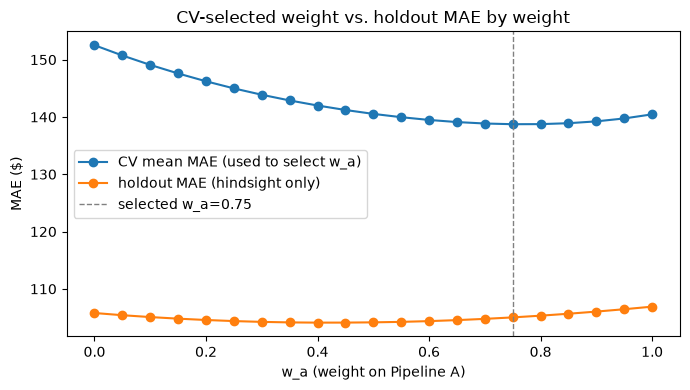

CV curve minimum is at w_a = 0.75
Holdout curve minimum is at w_a = 0.4, MAE = 104.108
At the CV-selected w_a=0.75, holdout MAE = 105.021


In [13]:
holdout_w_grid = []
for w in W_GRID:
    blend = w * holdout_pred_a + (1 - w) * holdout_pred_b
    holdout_w_grid.append({"w_a": w, "holdout_MAE": mae(holdout["posted_rate"].to_numpy(), blend)})
holdout_w_df = pd.DataFrame(holdout_w_grid)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid_df.sort_values("w_a")["w_a"], grid_df.sort_values("w_a")["mean_MAE"], marker="o", label="CV mean MAE (used to select w_a)")
ax.plot(holdout_w_df["w_a"], holdout_w_df["holdout_MAE"], marker="o", label="holdout MAE (hindsight only)")
ax.axvline(BEST_W, color="gray", ls="--", lw=1, label=f"selected w_a={BEST_W}")
ax.set_xlabel("w_a (weight on Pipeline A)")
ax.set_ylabel("MAE ($)")
ax.legend()
ax.set_title("CV-selected weight vs. holdout MAE by weight")
plt.tight_layout()
plt.show()

print("CV curve minimum is at w_a =", grid_df.iloc[0]["w_a"])
best_holdout_row = holdout_w_df.sort_values("holdout_MAE").iloc[0]
print(f"Holdout curve minimum is at w_a = {best_holdout_row['w_a']}, MAE = {best_holdout_row['holdout_MAE']:.3f}")
print(f"At the CV-selected w_a={BEST_W}, holdout MAE = {holdout_w_df.loc[holdout_w_df['w_a'] == BEST_W, 'holdout_MAE'].iloc[0]:.3f}")

## Summary — Pipeline C results (Aug 25 rebuild)

**The ensemble helps this time — unlike the Aug 24 version.** With each pipeline's best known
config (Component A = XGBoost + `market_trend`, Component B = LightGBM Stage 2), CV grid
search picked `w_a=0.75` (75% Pipeline A / 25% Pipeline B), mean CV MAE $138.74. Applied once
to the untouched Sep-Oct holdout:

| Model | MAE | RMSE | SMAPE | MASE |
|---|---|---|---|---|
| Pipeline A alone (XGBoost + `market_trend`) | $106.90 | $632.66 | 3.85% | 0.550 |
| Pipeline B alone (LightGBM Stage 2) | $105.79 | $632.51 | 3.85% | 0.544 |
| **Pipeline C (ensemble, w_a=0.75)** | **$105.02** | **$632.30** | **3.77%** | **0.540** |

The ensemble beats *both* components on *every* metric — a real, if modest, ~0.7% MAE
improvement over Pipeline B alone. The post-hoc (hindsight-only, not used for selection)
weight-vs-holdout-MAE curve bottoms out lower still, at `w_a=0.4` (MAE $104.11) — CV still
isn't perfectly calibrated to the holdout optimum (0.75 selected vs. 0.4 in hindsight,
consistent with fold 2's known Stage-1 bias still nudging the CV search toward A somewhat),
but this time **both** the CV-selected weight and the hindsight-optimal weight land in the
region where blending helps, not hurts.

**Why this ensemble works when the Aug 24 one didn't.** The earlier failure mode was
diagnosed as fold 2's Stage-1 bias being large enough (and specific enough — a genuine,
undiagnosable-in-advance trend reversal) that blending toward the weaker component (old
Pipeline A, 17% worse) pulled the CV-selected weight to a point that actively hurt the
holdout. With Pipeline A now within ~1% of Pipeline B, the same fold-2 distortion still
biases the CV search (0.75 vs. the hindsight-optimal 0.4), but the two components are close
enough in quality that blending toward either one, even somewhat past the honest optimum,
still lands in genuinely-helps territory rather than genuinely-hurts territory. Ensembling
"is nearly free accuracy" (KNOWLEDGE.md §5.1) held this time — it just needed the components
to be roughly comparable first, not one propping up a clearly weaker other.

**Recommendation**: the ensemble is now the best single number on the holdout ($105.02) and
costs relatively little extra (both components are already being trained/maintained
individually). Worth using for the final Nov-Dec run if the modest gain over Pipeline B alone
($105.79 -> $105.02) is judged worth the added complexity (two feature pipelines, two models,
a blend weight to carry through to `validation.csv`/`december-chart-inputs.csv`); Pipeline B
alone remains a simpler, nearly-as-strong fallback.